In [1]:
%matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np
import math

### Equivalent circuit model
![alt text](equivalent_quartz_crystal_model.png "Equivalent Circuit Model")

**Basic impendance equations**

$
Z = R + jX \\
Z_c = \frac{1}{j \omega C} = -j \frac{1}{\omega C}\\
Z_l = j \omega L \\
\omega = 2\pi f \\
$

**Quartz Crystal Impedance Calculations**  

Series RCL circuit impedance component

$
Z_s = R_s + Z_Cs + Z_Ls \\
Z_s = R + j (-\frac{1}{\omega C} + \omega L) \\
|Z_s| = \sqrt{R^2 + (-\frac{1}{\omega C} + \omega L)^2} \\
|Z_s| = \sqrt{R^2 + (-X_{Cs} + X_{Ls})^2}
$

Net impedance of the circuit, accounting for parallel capacitance

$
\frac{1}{Z_p} = \frac{1}{Z_s} + \frac{1}{Z_{C_p}}\\
\frac{1}{|Z_p|} = \frac{1}{Z_s} + \frac{1}{X_{C_p}}\\
|Z_p| = \frac{Z_s \times X_{C_p}}{|Z_s| + X_{C_p}}
$

In [2]:
class QuartzCrystal:
    def __init__(self, R, L, Cs, Cp):
        self.R = R
        self.L = L
        self.Cs = Cs
        self.Cp = Cp
    
    def X_Ls(self, f):
        return 1j*2*math.pi*f*self.L
    
    def X_Cp(self, f):
        return -1j/(2*math.pi*f*self.Cp)
    
    def X_Cs(self, f):
        return -1j/(2*math.pi*f*self.Cs)
    
    # Series component of the circuit
    def Zs(self, f):
        return self.R + self.X_Ls(f) + self.X_Cs(f)
    
    # Net impedance of the circuit
    def Zp(self, f):
        Zs = self.Zs(f)
        X_Cp = self.X_Cp(f)
        return (Zs*X_Cp)/(Zs+X_Cp)
    
    @property
    def f_series(self):
        Ls = self.L
        Cs = self.Cs
        return 1/(2*math.pi*math.sqrt(Ls*Cs))
    
    @property
    def f_parallel(self):
        Cp = self.Cp
        Cs = self.Cs
        Ls = self.L
        var_x = Ls*(Cp*Cs)/(Cp+Cs)
        return 1/(2*math.pi*math.sqrt(var_x))

In [3]:
class CrystalPlotter:
    @staticmethod
    def fetch_frequencies(crystal, start=0.95, end=1.05):
        f_mid = (crystal.f_series + crystal.f_parallel)/2.0
        f_range = np.linspace(start*f_mid, end*f_mid, 10**3)
        return f_range
        
    @staticmethod
    def plot_impedance_frequency_response(crystal):
        @np.vectorize
        def get_impedance(f):
            return abs(crystal.Zp(f))
        fig, ax = plt.subplots()
        ax.set_title('Impedance frequency response')
        ax.set_xlabel('f')
        ax.set_ylabel('Zp')
        # f_range = np.geomspace(9*10**6, 11*10**6, endpoint=True)
        f_range = CrystalPlotter.fetch_frequencies(crystal, 0.5, 1.5)
        ax.plot(f_range, get_impedance(f_range))
        # ax.axvline(x=crystal.f_parallel, color='g')
        ax.axvline(x=crystal.f_series, color='r', linestyle='dashed', linewidth=1)
        ax.axvline(x=crystal.f_parallel, color='g', linestyle='dashed', linewidth=1)
        fig.show()
    
    @staticmethod
    def plot_reactance_frequency_response(crystal):
        @np.vectorize
        def get_reactance(f):
            return crystal.Zp(f).imag
        fig, ax = plt.subplots()
        ax.set_title('Reactance frequency response')
        ax.set_xlabel('f')
        ax.set_ylabel('Xp')
        f_range = CrystalPlotter.fetch_frequencies(crystal)
        ax.plot(f_range, get_reactance(f_range))
        ax.axvline(x=crystal.f_series, color='r', linestyle='dashed', linewidth=1)
        ax.axvline(x=crystal.f_parallel, color='g', linestyle='dashed', linewidth=1)
        fig.show()

In [4]:
crystal = QuartzCrystal(R=6.4, L=2.546*10**-3, 
                        Cs=0.09972*10**-12, Cp=28.68*10**-12)
# crystal.Zp(10*10**6)
print("Fs: {}".format(crystal.f_series))
print("Fp: {}".format(crystal.f_parallel))
print("Zmin: {}".format(abs(crystal.Zp(crystal.f_series))))
print("Zmax(local): {}".format(abs(crystal.Zp(crystal.f_parallel))))

Fs: 9988489.032042261
Fp: 10005838.889312856
Zmin: 6.3995753957564165
Zmax(local): 48064.4412480674


<IPython.core.display.Javascript object>


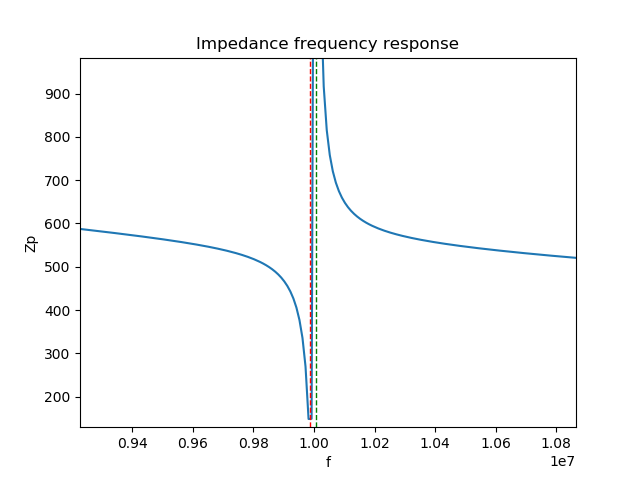

<IPython.core.display.Javascript object>


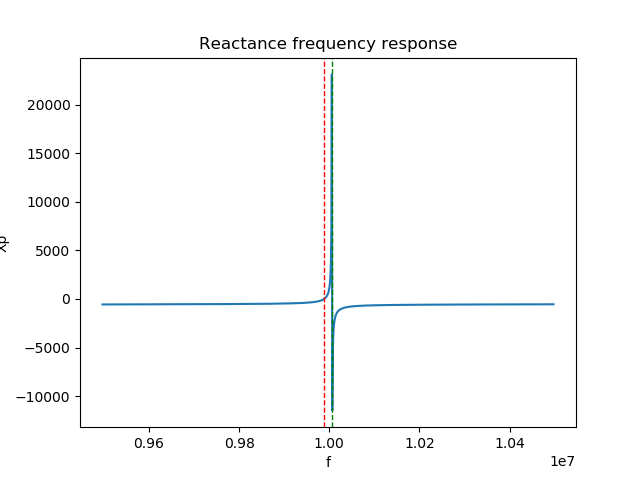

In [5]:
CrystalPlotter.plot_impedance_frequency_response(crystal)
CrystalPlotter.plot_reactance_frequency_response(crystal)

### Expected impedance frequency response
![alt text](impedance_vs_frequency.png "Frequency response")
### Expected reactance frequency response
![alt text](reactance_vs_frequency.png "Frequency response")

### Resonant frequency calculations

Resonant frequency of the RLC series component

$
\text{When $Xs = 0$, $f = f_s$}\\   
\frac{-1}{\omega C} + \omega L = 0\\
\omega L = \frac{1}{\omega C}, \space \omega = 2 \pi f\\
(2 \pi fs)^2 = \frac{1}{LC}\\
2 \pi f = \frac{1}{\sqrt{LC}}, \space f > 0\\
f_s = \frac{1}{2 \pi \sqrt{L_s C_s}}
$

Resonant frequency of the entire circuit occurs when the reactance of the series component is equivalent to the reactance of the parallel capacitance component.

$
\text{When $Xs = X_{C_p}$,  $f = f_p$}\\
\frac{-1}{\omega C_s} + \omega L = \frac{-1}{\omega C_p}\\
\omega L = \frac{1}{\omega C_s} - \frac{1}{\omega C_p}\\
\omega L = \frac{1}{\omega} (\frac{C_p - C_s}{C_s C_p})\\
\omega ^2 = \frac{1}{L(\frac{C_s C_p}{C_p - C_s})}\\
f_p = \frac{1}{2 \pi \sqrt{L (\frac{C_s C_p}{C_p - C_s})}}
$

### Q Factor
Q factor is a masure of the amount of energy loss relative to the amount of energy stored within a system. Generally higher Q factor infers higher energy efficiency. Q factor in an RC circuit will be determined by the bandwidth, dampening and inductance of the circuit. 

#### Q Factor of Quartz Crystal
$
Q = \frac{X_L}{R} = \frac{2 \pi fL}{R}
$